In [1]:
import pandas as pd
import numpy as np

# Read climate and financial data
df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv", index_col=0)
df = df.rename(columns={"index_nsa": "hpi"})

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_81108/3422223062.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv", index_col=0)


In [2]:
# Subset for data in California from 2018-2020
df_ca_2018_2020 = df[
    (df['yr'].between(2018, 2020)) & (df['state'] == 'CALIFORNIA') ]

In [3]:
# Read data from California wildfire insurance
wildfire_insurance = pd.read_excel("../../02_processed_data/Residential-Property-Coverage-Amounts-Wildfire-Risk-and-Losses_Export.xlsx", 
sheet_name="Export_all", header=2)

In [4]:
wildfire_insurance.head()

,Source,Calendar Year,Policy Type,ZIP Code,Avg Cov A,Avg Cov C,Avg PPC Class,Avg Fire Risk,Count N,Count L,...,NonCat CovC Smoke Count,Cat CovA Fire Losses,Cat CovA Fire Count,Cat CovA Smoke Losses,Cat CovA Smoke Count,Cat CovC Fire Losses,Cat CovC Fire Count,Cat CovC Smoke Losses,Cat CovC Smoke Count,County
0,All Companies,18,CO,90001,54454.53,79376.32,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,Los Angeles
1,All Companies,19,CO,90001,123721.07,154296.95,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,Los Angeles
2,All Companies,20,CO,90001,23037.32,44099.54,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,Los Angeles
3,All Companies,18,DO,90001,230821.52,20971.27,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,Los Angeles
4,All Companies,19,DO,90001,243257.71,21405.82,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,Los Angeles


In [5]:
# Subset data from 2018-2020, with homeowner premium insurance type
wildfire_insurance['Calendar Year'] += 2000
wildfire_insurance_18_20 = wildfire_insurance[
    (wildfire_insurance['Policy Type'] == "HO") & (wildfire_insurance['Calendar Year'].between(2018, 2020))]

# Keep the column of interest
wildfire_insurance_18_20 = wildfire_insurance_18_20[["Calendar Year", "ZIP Code", "Earned Prem", "Earned Exp"]]

In [6]:
# Load crosswalk file
crosswalk = pd.read_excel("../../01_original_data/ZIP_COUNTY_122020.xlsx", dtype={'ZIP': str, 'COUNTY': str})

# Keep only the data from California
crosswalk_ca = crosswalk[crosswalk['ZIP'].str.startswith('9')]

In [7]:
# Force the zipcode to be a string
wildfire_insurance_18_20['ZIP Code'] = wildfire_insurance_18_20['ZIP Code'].astype(str)

# Keep only the largest res_ratio county for each zipcode to avoid 1 to many merge issue
crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)
crosswalk_ca_sorted = crosswalk_ca.sort_values(by=['ZIP', 'RES_RATIO'], ascending=[True, False])
crosswalk_main = crosswalk_ca_sorted.drop_duplicates(subset=['ZIP'], keep='first')

# Merge the wildfire_insurance file with the crosswalk
wildfire_zip = wildfire_insurance_18_20.merge(
    crosswalk_main[['ZIP', 'COUNTY']], 
    left_on='ZIP Code', right_on='ZIP', 
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_81108/3822516419.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)


In [8]:
# Add the 0 to county fips code 
df_ca_2018_2020["county_fips5"] = df_ca_2018_2020["county_fips5"].astype(str).str.zfill(5)

wildfire_zip = wildfire_zip.rename(columns={"COUNTY": "county_fips5", "Calendar Year": "yr"})

# Merge and get the final dataframe
final_df = wildfire_zip.merge(
    df_ca_2018_2020,
    on=['county_fips5', 'yr'],
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_81108/3499580463.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ca_2018_2020["county_fips5"] = df_ca_2018_2020["county_fips5"].astype(str).str.zfill(5)


In [9]:
final_df = final_df.drop(columns=["ZIP"])

# Create premium per unit to show average earned premium for each housing unit
final_df = final_df[final_df['Earned Exp'] > 0]
final_df['prem_per_unit'] = final_df['Earned Prem'] / final_df['Earned Exp']

In [10]:
final_df['total_amt_purchase'] = pd.to_numeric(final_df['total_amt_purchase'], errors='coerce')
final_df['total_home_purchase'] = pd.to_numeric(final_df['total_home_purchase'], errors='coerce')

final_df['real_gdp'] = pd.to_numeric(final_df['real_gdp'], errors='coerce')
final_df['total_population'] = pd.to_numeric(final_df['total_population'], errors='coerce')

In [11]:
# Create average home mortgage amount per housing unit
final_df['mortgage_per_unit'] = final_df['total_amt_purchase'] / final_df['total_home_purchase']

# Create real gdp per capita
final_df['gdp_per_capita'] = final_df['real_gdp'] / final_df['total_population']

# Create debt to income ratio
final_df['debt_income_ratio'] = final_df['gdp_per_capita'] / final_df['mortgage_per_unit']

In [12]:
# Drop rows with any missing predictors (from climate hazard and financial predictors)
final_df_cleaned = final_df.dropna()

In [13]:
final_df.head()

,yr,ZIP Code,Earned Prem,Earned Exp,county_fips5,hpi_change,hpi,state,flood_frequency,flood_property_damage,...,unemployment_rate,prop_rate,county_fips,total_home_purchase,total_amt_purchase,total_population,prem_per_unit,mortgage_per_unit,gdp_per_capita,debt_income_ratio
0,2018,90001,1233018,1799,06037,6.71,1566.79,CALIFORNIA,0.0,0.0,...,4.6,1.175,6037.0,52076.0,3.046519e+10,10061533.0,685.390773,585014.017974,73.556222,0.000126
1,2019,90001,1351943,1863,06037,3.50,1621.68,CALIFORNIA,0.0,0.0,...,4.5,1.182,6037.0,53991.0,3.281898e+10,10011602.0,725.680623,607860.106314,76.696952,0.000126
2,2020,90001,1496492,1908,06037,2.72,1665.85,CALIFORNIA,2.0,0.0,...,12.3,1.171,6037.0,55477.0,3.715788e+10,9996634.0,784.324948,669789.011662,72.931447,0.000109
3,2018,90002,1721682,2517,06037,6.71,1566.79,CALIFORNIA,0.0,0.0,...,4.6,1.175,6037.0,52076.0,3.046519e+10,10061533.0,684.021454,585014.017974,73.556222,0.000126
4,2019,90002,1923430,2660,06037,3.50,1621.68,CALIFORNIA,0.0,0.0,...,4.5,1.182,6037.0,53991.0,3.281898e+10,10011602.0,723.093985,607860.106314,76.696952,0.000126


In [583]:
# Define hazard and financial predictors
climate_financial_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size", "deaths_hurricane", "injuries_hurricane", "damage_hurricane",
    "unemployment_rate", "prop_rate", "debt_income_ratio"
]

In [541]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import bambi as bmb
import arviz as az

final_df["log_prem_per_unit"] = np.log1p(final_df["prem_per_unit"])

vars_for_model = ["log_prem_per_unit"] + climate_financial_vars
final_df_lagged_bayes = final_df.dropna(subset=vars_for_model).reset_index(drop=True)

scaler = StandardScaler()
final_df_lagged_bayes[climate_financial_vars] = scaler.fit_transform(
    final_df_lagged_bayes[climate_financial_vars]
)

print(final_df_lagged_bayes[climate_financial_vars].mean().head())
print(final_df_lagged_bayes[climate_financial_vars].std(ddof=0).head())

formula_fe = "log_prem_per_unit ~ " + " + ".join(climate_financial_vars)
model_simple = bmb.Model(formula=formula_fe, data=final_df_lagged_bayes)
results_simple = model_simple.fit(draws=1000, tune=1000, chains=2, cores=1)

az.summary(results_simple, round_to=3)


flood_frequency              2.047305e-17
flood_property_damage        1.023652e-17
flood_duration_hours         0.000000e+00
heat_stress_index           -8.189219e-17
drought_annual_mean_index   -3.070957e-17
dtype: float64
flood_frequency              1.0
flood_property_damage        1.0
flood_duration_hours         1.0
heat_stress_index            1.0
drought_annual_mean_index    1.0
dtype: float64


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.461,0.004,0.453,0.469,0.0,0.0,3325.697,1634.932,1.001
Intercept,7.038,0.006,7.028,7.051,0.0,0.0,3710.738,1607.017,1.000
flood_frequency,0.018,0.007,0.006,0.032,0.0,0.0,3013.269,1395.952,1.002
flood_property_damage,0.014,0.007,0.002,0.027,0.0,0.0,3151.853,1484.551,0.999
flood_duration_hours,-0.042,0.007,-0.056,-0.028,0.0,0.0,3158.931,1334.341,1.001
heat_stress_index,-0.088,0.008,-0.103,-0.073,0.0,0.0,2758.190,1530.486,1.001
drought_annual_mean_index,0.038,0.007,0.025,0.051,0.0,0.0,3218.792,1616.366,1.001
fire_frequency,-0.010,0.008,-0.025,0.005,0.0,0.0,2685.519,1608.338,1.003
fire_size,0.015,0.007,0.002,0.028,0.0,0.0,2903.931,1586.439,1.000
unemployment_rate,0.010,0.007,-0.004,0.023,0.0,0.0,2949.253,1633.434,1.000


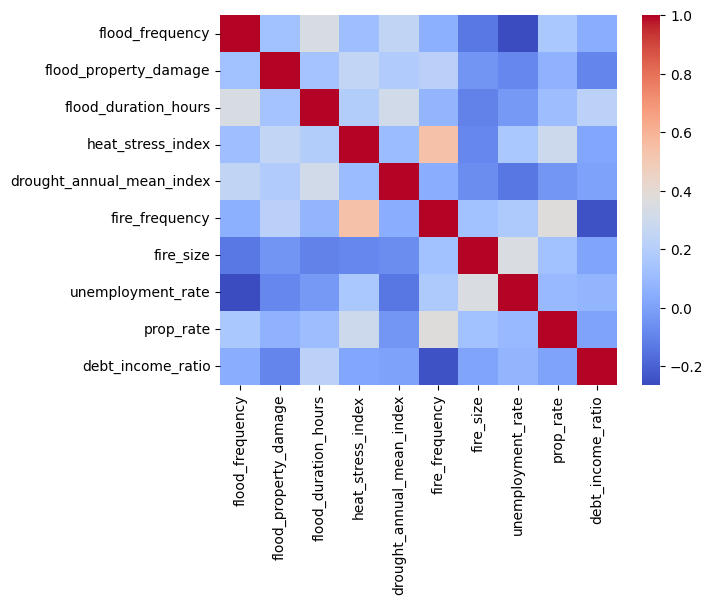

In [493]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = final_df_lagged_bayes[climate_financial_vars].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

array([[<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'flood_frequency'}>,
        <Axes: title={'center': 'flood_frequency'}>],
       [<Axes: title={'center': 'flood_property_damage'}>,
        <Axes: title={'center': 'flood_property_damage'}>],
       [<Axes: title={'center': 'flood_duration_hours'}>,
        <Axes: title={'center': 'flood_duration_hours'}>],
       [<Axes: title={'center': 'heat_stress_index'}>,
        <Axes: title={'center': 'heat_stress_index'}>],
       [<Axes: title={'center': 'drought_annual_mean_index'}>,
        <Axes: title={'center': 'drought_annual_mean_index'}>],
       [<Axes: title={'center': 'fire_frequency'}>,
        <Axes: title={'center': 'fire_frequency'}>],
       [<Axes: title={'center': 'fire_size'}>,
        <Axes: title={'center': 'fire_size'}>],
       [<Axes: title={'center': 'unem

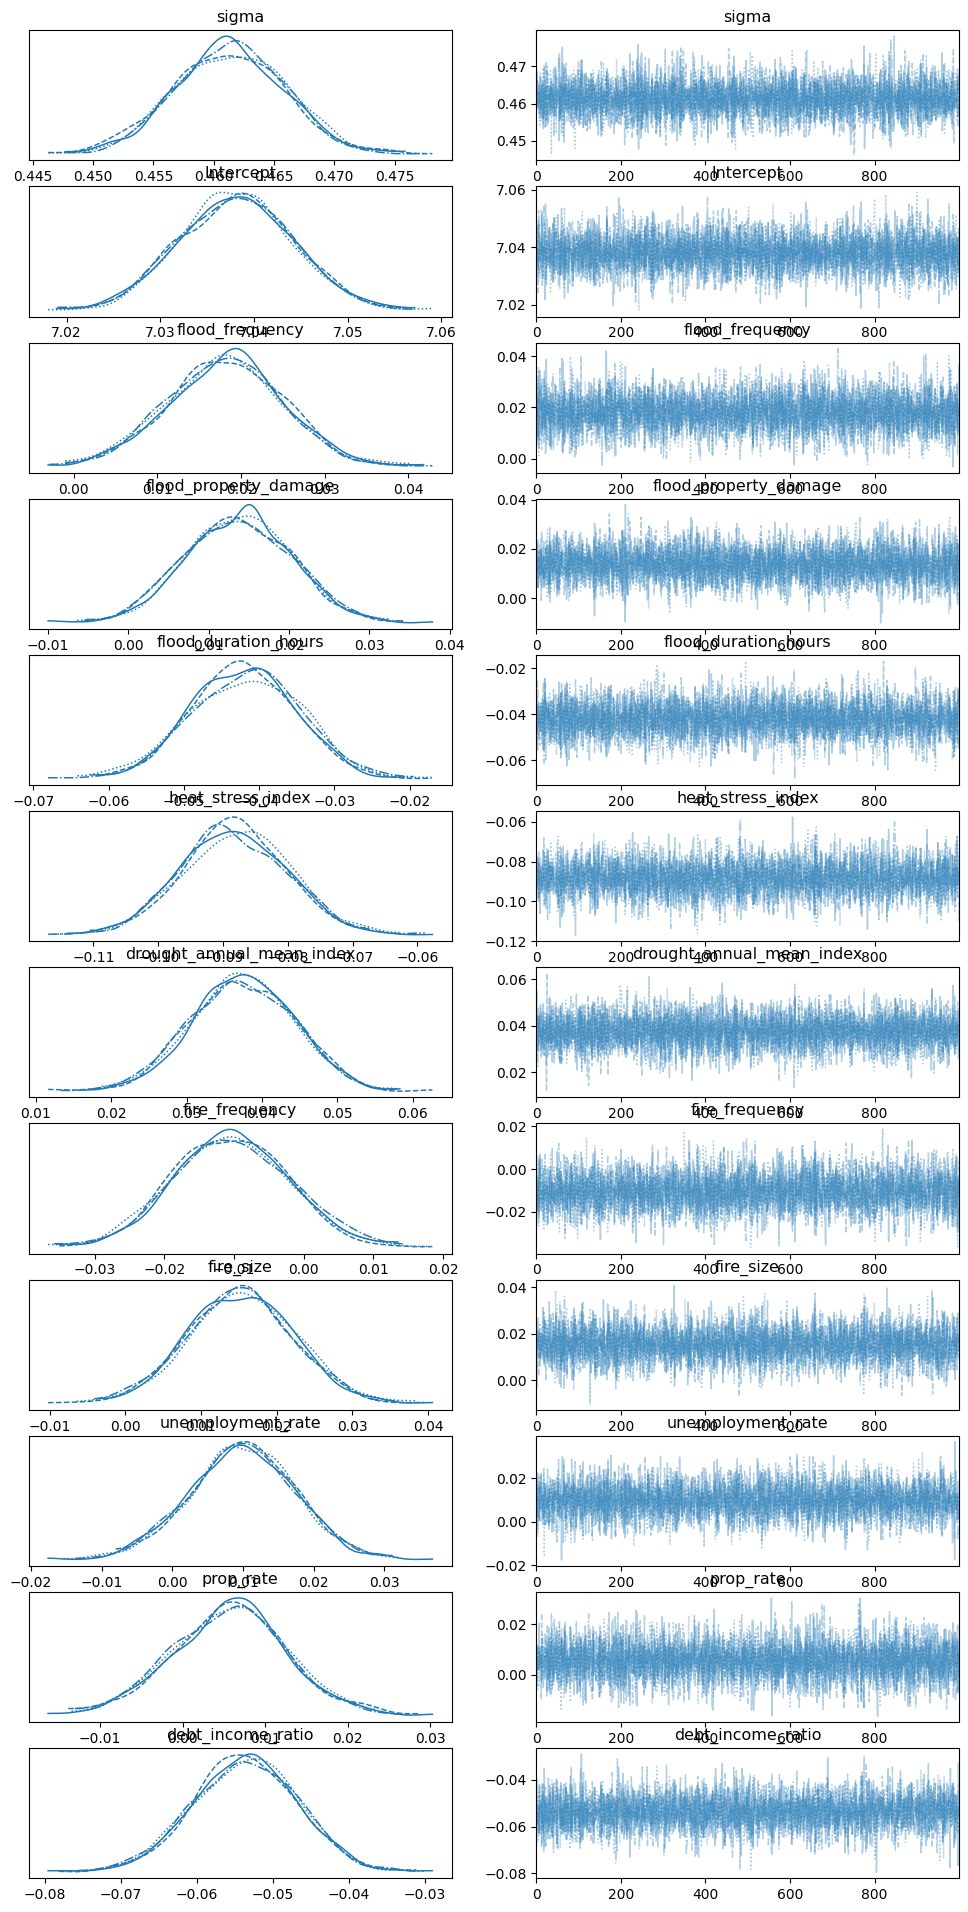

In [494]:
az.plot_trace(results_simple)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='log_prem_per_unit'>

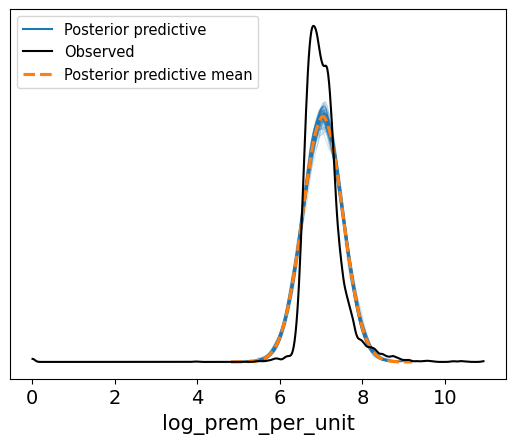

In [499]:
# Posterior predictive check
ppc_preds = model_simple.predict(results_simple, kind="pps", inplace=False)

idata_ppc = results_simple.copy()
idata_ppc.add_groups(posterior_predictive=ppc_preds.posterior_predictive)

az.plot_ppc(idata_ppc, var_names=["log_prem_per_unit"], group="posterior", num_pp_samples=100)

In [548]:
import numpy as np
import matplotlib.pyplot as plt

model_simple.predict(results_simple, kind="pps", inplace=True)

r2_result = az.r2_score(
    y_true=results_simple.observed_data["log_prem_per_unit"],
    y_pred=results_simple.posterior_predictive["log_prem_per_unit"]
)

print("=" * 60)
print("BAYESIAN R²")
print("=" * 60)
print(f"R² mean: {r2_result['r2']:.3f}")
print(f"R² std: {r2_result['r2_std']:.3f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


BAYESIAN R²
R² mean: 0.758
R² std: 0.216


In [543]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import bambi as bmb
import arviz as az

final_df["log_prem_per_unit"] = np.log1p(final_df["prem_per_unit"])

vars_for_model = ["log_prem_per_unit"] + climate_financial_vars
final_df_bayes = final_df.dropna(subset=vars_for_model).reset_index(drop=True)

scaler = StandardScaler()
final_df_bayes[climate_financial_vars] = scaler.fit_transform(
    final_df_bayes[climate_financial_vars]
)

final_df_bayes = final_df_bayes.rename(columns={"ZIP Code": "zipcode"})

formula_re = "log_prem_per_unit ~ " + " + ".join(climate_financial_vars) + " + (1|zipcode)"

model_random = bmb.Model(formula=formula_re, data=final_df_bayes)

results_random = model_random.fit(draws=1000, tune=1000, chains=4, cores=1)

az.summary(results_random, round_to=3)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 60 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.122,0.001,0.119,0.125,0.000,0.000,2616.842,2822.184,1.002
Intercept,7.029,0.012,7.007,7.052,0.001,0.000,219.484,512.334,1.014
flood_frequency,-0.002,0.003,-0.007,0.003,0.000,0.000,3146.163,3016.862,1.001
flood_property_damage,-0.010,0.002,-0.014,-0.005,0.000,0.000,1964.238,2808.617,1.001
flood_duration_hours,-0.004,0.002,-0.008,0.001,0.000,0.000,3913.054,3326.344,1.001
...,...,...,...,...,...,...,...,...,...
1|zipcode[96155],0.182,0.073,0.049,0.324,0.001,0.001,3061.167,2361.147,1.001
1|zipcode[96158],0.438,0.071,0.306,0.573,0.001,0.001,2521.184,2550.655,1.001
1|zipcode[96160],1.051,0.075,0.913,1.192,0.001,0.002,3130.875,2163.386,1.001
1|zipcode[96161],0.569,0.071,0.436,0.703,0.001,0.001,3155.993,2574.182,1.003


In [547]:
import numpy as np
import matplotlib.pyplot as plt

model_random.predict(results_random, kind="pps", inplace=True)

r2_result = az.r2_score(
    y_true=results_random.observed_data["log_prem_per_unit"],
    y_pred=results_random.posterior_predictive["log_prem_per_unit"]
)

print("=" * 60)
print("BAYESIAN R²")
print("=" * 60)
print(f"R² mean: {r2_result['r2']:.3f}")
print(f"R² std: {r2_result['r2_std']:.3f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


BAYESIAN R²
R² mean: 0.629
R² std: 0.178


In [550]:
# LOO Comparison
print("=" * 60)
print("MODEL COMPARISON WITH LOO")
print("=" * 60)

results_simple = model_simple.fit(
    draws=1000, tune=1000, chains=4, cores = 1,
    idata_kwargs={"log_likelihood": True}
)

results_random = model_random.fit(
    draws=1000, tune=1000, chains=4, cores = 1,
    idata_kwargs={"log_likelihood": True}
)

MODEL COMPARISON WITH LOO


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 71 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


NameError: name 'results_fixed' is not defined

In [551]:
# LOO Comparison
print("=" * 60)
print("MODEL COMPARISON WITH LOO")
print("=" * 60)

results_simple = model_simple.fit(
    draws=1000, tune=1000, chains=4, cores = 1,
    idata_kwargs={"log_likelihood": True}
)

results_random = model_random.fit(
    draws=1000, tune=1000, chains=4, cores = 1,
    idata_kwargs={"log_likelihood": True}
)

compare_dict = {
    "fixed": results_simple,
    "random": results_random
}
comparison = az.compare(compare_dict, ic="loo")
print(comparison)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


        rank     elpd_loo        p_loo    elpd_diff  weight          se  \
random     0  2905.991537  1435.512132     0.000000     1.0  606.173022   
fixed      1 -3600.126941    33.731075  6506.118479     0.0  255.584975   

               dse  warning scale  
random    0.000000     True   log  
fixed   562.857656     True   log  


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='log_prem_per_unit'>

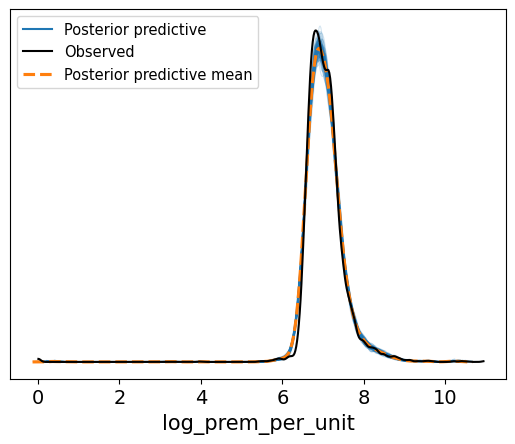

In [514]:
ppc_preds_re = model_random.predict(results_random, kind="pps", inplace=False)

az.plot_ppc(ppc_preds_re , var_names=["log_prem_per_unit"], group="posterior", num_pp_samples=100)

In [565]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import bambi as bmb
import arviz as az

# Log transformation
final_df = final_df.copy()
final_df["log_prem_per_unit"] = np.log1p(final_df["prem_per_unit"])

# Drop NA only for variables we need
vars_for_model = ["log_prem_per_unit"] + climate_financial_vars + ["yr", "ZIP Code"]
df = final_df.dropna(subset=vars_for_model).reset_index(drop=True)

# Rename zipcode column
df = df.rename(columns={"ZIP Code": "zipcode"})

# Split train/test by year
train_df = df[df["yr"].isin([2018, 2019])].copy()
test_df  = df[df["yr"] == 2020].copy()

# Scale predictors: fit on train, transform both
scaler = StandardScaler()
train_df[climate_financial_vars] = scaler.fit_transform(train_df[climate_financial_vars])
test_df[climate_financial_vars]  = scaler.transform(test_df[climate_financial_vars])

# Build and fit model on train only
formula_re = "log_prem_per_unit ~ " + " + ".join(climate_financial_vars) + " + (1|zipcode)"
model_random = bmb.Model(formula=formula_re, data=train_df)

results_random = model_random.fit(draws=1000, tune=1000, chains=4, cores=1)

print(az.summary(results_random, round_to=3))


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 46 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
sigma                  0.125  0.002   0.121    0.130      0.000    0.000   
Intercept              6.988  0.010   6.969    7.008      0.000    0.000   
flood_frequency        0.015  0.004   0.007    0.024      0.000    0.000   
flood_property_damage -0.008  0.003  -0.014   -0.002      0.000    0.000   
flood_duration_hours  -0.009  0.004  -0.016   -0.003      0.000    0.000   
...                      ...    ...     ...      ...        ...      ...   
1|zipcode[96155]       0.065  0.091  -0.112    0.231      0.001    0.002   
1|zipcode[96158]       0.347  0.091   0.176    0.508      0.001    0.001   
1|zipcode[96160]       0.779  0.091   0.606    0.947      0.001    0.002   
1|zipcode[96161]       0.475  0.091   0.293    0.639      0.001    0.002   
1|zipcode[96162]       1.031  0.089   0.856    1.193      0.001    0.002   

                       ess_bulk  ess_tail  r_hat  
sigma                  1537.976  236

In [567]:
seen_zip = set(train_df["zipcode"].unique())
test_df_seen = test_df[test_df["zipcode"].isin(seen_zip)].copy()

test_idata = model_random.predict(
    results_random,
    data=test_df_seen,
    kind="mean",
    inplace=False
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:843: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


In [584]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import bambi as bmb
import arviz as az
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = final_df.copy()
df["log_prem_per_unit"] = np.log1p(df["prem_per_unit"])
df = df.rename(columns={"ZIP Code": "zipcode"})

vars_for_model = ["log_prem_per_unit", "yr", "zipcode"] + climate_financial_vars
df = df.dropna(subset=vars_for_model).reset_index(drop=True)

# Train/test split
train_df = df[df["yr"].isin([2018, 2019])].copy()
test_df  = df[df["yr"] == 2020].copy()

seen_zip = set(train_df["zipcode"].unique())
test_seen = test_df[test_df["zipcode"].isin(seen_zip)].copy().reset_index(drop=True)

# Scale the variables
scaler = StandardScaler()
train_df[climate_financial_vars] = scaler.fit_transform(train_df[climate_financial_vars])
test_seen[climate_financial_vars] = scaler.transform(test_seen[climate_financial_vars])

# Fit random-intercept model
formula_re = "log_prem_per_unit ~ " + " + ".join(climate_financial_vars) + " + (1|zipcode)"
model_random = bmb.Model(formula=formula_re, data=train_df)

results_random = model_random.fit(draws=1000, tune=1000, chains=4, cores=1)

# Predict on 2020 (mean)
test_idata = model_random.predict(
    results_random,
    data=test_seen,
    kind="mean",
    inplace=False
)

y_true = test_seen["log_prem_per_unit"].values

cand = []
for v in test_idata.posterior.data_vars:
    da = test_idata.posterior[v]
    non_cd_dims = [d for d in da.dims if d not in ("chain", "draw")]
    if len(non_cd_dims) == 1:
        cand.append((v, non_cd_dims[0], da))

if len(cand) == 0:
    raise ValueError(
        "No posterior variable with an observation dimension found. "
        "Try: print(list(test_idata.posterior.data_vars))"
    )

best = None
for v, obs_dim, da in cand:
    if da.sizes[obs_dim] == len(test_seen):
        best = (v, obs_dim, da)
        break
if best is None:
    best = cand[0]

pred_var, obs_dim, mu = best
print("Using posterior var:", pred_var, "| obs dim:", obs_dim, "| obs size:", mu.sizes[obs_dim])

y_pred = mu.stack(sample=("chain","draw")).mean("sample").values

# Model metrics
rmse = mean_squared_error(y_true, y_pred, squared=False)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("2020 test (seen zipcodes):")
print("RMSE:", rmse, "MAE:", mae, "R2:", r2)

y_true_raw = np.expm1(y_true)
y_pred_raw = np.expm1(y_pred)
rmse_raw = mean_squared_error(y_true_raw, y_pred_raw, squared=False)
mae_raw  = mean_absolute_error(y_true_raw, y_pred_raw)

print("2020 raw scale:")
print("RMSE:", rmse_raw, "MAE:", mae_raw)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 46 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:843: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


Using posterior var: mu | obs dim: __obs__ | obs size: 1823


TypeError: got an unexpected keyword argument 'squared'

In [585]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_true = np.asarray(y_true).ravel()
y_pred = np.asarray(y_pred).ravel()

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("2020 test (seen zipcodes):")
print("RMSE:", rmse, "MAE:", mae, "R2:", r2)

2020 test (seen zipcodes):
RMSE: 0.3589006896082331 MAE: 0.32954964962704747 R2: 0.3327283452641976


In [617]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import bambi as bmb
import arviz as az

climate_financial_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size",
    "unemployment_rate", "prop_rate", "debt_income_ratio"
]

final_df["log_prem_per_unit"] = np.log1p(final_df["prem_per_unit"])

vars_for_model = ["log_prem_per_unit"] + climate_financial_vars
final_df_bayes = final_df.dropna(subset=vars_for_model).reset_index(drop=True)

scaler = StandardScaler()
final_df_bayes[climate_financial_vars] = scaler.fit_transform(
    final_df_bayes[climate_financial_vars])

# Scale year
final_df_bayes["yr_scaled"] = (final_df_bayes["yr"] - final_df_bayes["yr"].min())

final_df_bayes = final_df_bayes.rename(columns={"ZIP Code": "zipcode"})

formula = f"""
log_prem_per_unit ~ 
    {' + '.join(climate_financial_vars)} + 
    (1 + yr_scaled | zipcode)
"""

model = bmb.Model(formula, data=final_df_bayes)

results = model.fit(
    draws=1000, 
    tune=1000, 
    chains=4, 
    cores=1,
    idata_kwargs={"log_likelihood": True},
    target_accept=0.95 
)

print("Model fitted successfully!")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset, yr_scaled|zipcode_sigma, yr_scaled|zipcode_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 151 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Model fitted successfully!

MODEL DIAGNOSTICS


KeyError: 'var names: "[\'1 + yr_scaled|zipcode\'] are not present" in dataset'

In [622]:
import numpy as np
import matplotlib.pyplot as plt

model.predict(results, kind="pps", inplace=True)

r2_result = az.r2_score(
    y_true=results.observed_data["log_prem_per_unit"],
    y_pred=results.posterior_predictive["log_prem_per_unit"]
)

print("=" * 60)
print("BAYESIAN R²")
print("=" * 60)
print(f"R² mean: {r2_result['r2']:.3f}")
print(f"R² std: {r2_result['r2_std']:.3f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


BAYESIAN R²
R² mean: 0.629
R² std: 0.178


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='log_prem_per_unit'>

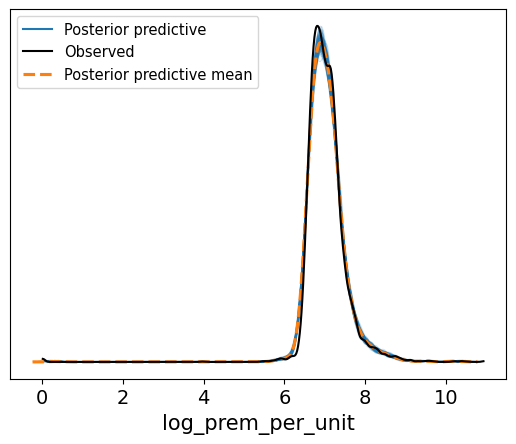

In [623]:
ppc_preds_re = model.predict(results, kind="pps", inplace=False)

az.plot_ppc(ppc_preds_re , var_names=["log_prem_per_unit"], group="posterior", num_pp_samples=100)

In [626]:
formula_re = "log_prem_per_unit ~ " + " + ".join(climate_financial_vars) + " + (1|zipcode)"

model_random = bmb.Model(formula=formula_re, data=final_df_bayes)

In [628]:
# LOO Comparison
print("=" * 60)
print("MODEL COMPARISON WITH LOO")
print("=" * 60)

results_random = model_random.fit(
    draws=1000, tune=1000, chains=4, cores = 1,
    idata_kwargs={"log_likelihood": True}
)

compare_dict = {
    "random slope": results,
    "random intercept": results_random
}
comparison = az.compare(compare_dict, ic="loo")
print(comparison)

MODEL COMPARISON WITH LOO


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, Intercept, flood_frequency, flood_property_damage, flood_duration_hours, heat_stress_index, drought_annual_mean_index, fire_frequency, fire_size, unemployment_rate, prop_rate, debt_income_ratio, 1|zipcode_sigma, 1|zipcode_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 68 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/py

                  rank     elpd_loo        p_loo   elpd_diff    weight  \
random slope         0  3123.289264  1965.963982    0.000000  0.898937   
random intercept     1  2897.664627  1451.248788  225.624636  0.101063   

                          se        dse  warning scale  
random slope      579.957761   0.000000     True   log  
random intercept  610.027006  62.346147     True   log  


In [629]:
# Extrapolate predictors
print("\n" + "=" * 60)
print("EXTRAPOLATING PREDICTORS")
print("=" * 60)

def extrapolate_predictors(df, vars_to_extrapolate, target_years):
    results = []
    
    for zipcode in df["zipcode"].unique():
        df_zip = df[df["zipcode"] == zipcode].sort_values("yr")
        
        row = {"zipcode": zipcode}
        
        for var in vars_to_extrapolate:
            years = df_zip["yr"].values
            values = df_zip[var].values
            
            slope = np.polyfit(years, values, 1)[0]
            intercept = np.polyfit(years, values, 1)[1]
            
            for target_year in target_years:
                row[f"{var}_{target_year}"] = slope * target_year + intercept
        
        results.append(row)
    
    return pd.DataFrame(results)

# Extrapolate for 2021-2023
future_predictors = extrapolate_predictors(
    final_df_bayes, 
    climate_financial_vars, 
    [2021, 2022, 2023]
)

# Forecast 2021-2023
print("\n" + "=" * 60)
print("FORECASTING 2021-2023")
print("=" * 60)

forecasts_all_years = []

for year in [2021, 2022, 2023]:
    print(f"\nForecasting {year}...")
    
    forecast_data = pd.DataFrame({
        "zipcode": final_df_bayes["zipcode"].unique(),
        "yr_scaled": year - final_df_bayes["yr"].min(),
    })
    
    for var in climate_financial_vars:
        forecast_data[var] = future_predictors[f"{var}_{year}"].values
    
    model.predict(results, data=forecast_data, kind="pps")
    predictions = results.posterior_predictive["log_prem_per_unit"]
    
    forecast_data["predicted_mean"] = np.exp(predictions.mean(dim=["chain", "draw"]).values)
    forecast_data["predicted_lower"] = np.exp(predictions.quantile(0.025, dim=["chain", "draw"]).values)
    forecast_data["predicted_upper"] = np.exp(predictions.quantile(0.975, dim=["chain", "draw"]).values)
    forecast_data["year"] = year
    
    forecasts_all_years.append(forecast_data)

# Combine the forecasts
final_forecasts = pd.concat(forecasts_all_years)

print("\nForecasts completed!")
print(final_forecasts.head())


EXTRAPOLATING PREDICTORS


/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_74080/3195838073.py:21: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, values, 1)[0]
/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_74080/3195838073.py:22: RankWarning: Polyfit may be poorly conditioned
  intercept = np.polyfit(years, values, 1)[1]
/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_74080/3195838073.py:21: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, values, 1)[0]
/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_74080/3195838073.py:22: RankWarning: Polyfit may be poorly conditioned
  intercept = np.polyfit(years, values, 1)[1]
/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_74080/3195838073.py:21: RankWarning: Polyfit may be poorly conditioned
  slope = np.polyfit(years, values, 1)[0]
/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_74080/3195838073.py:22: RankWarning: Polyfit may be poorly conditioned
  


FORECASTING 2021-2023

Forecasting 2021...

Forecasting 2022...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(



Forecasting 2023...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bambi/models.py:850: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(



Forecasts completed!
  zipcode  yr_scaled  flood_frequency  flood_property_damage  \
0   90001          3        -0.554992               -0.13883   
1   90002          3        -0.554992               -0.13883   
2   90003          3        -0.554992               -0.13883   
3   90004          3        -0.554992               -0.13883   
4   90005          3        -0.554992               -0.13883   

   flood_duration_hours  heat_stress_index  drought_annual_mean_index  \
0             -0.422891          -0.220303                   2.516706   
1             -0.422891          -0.220303                   2.516706   
2             -0.422891          -0.220303                   2.516706   
3             -0.422891          -0.220303                   2.516706   
4             -0.422891          -0.220303                   2.516706   

   fire_frequency  fire_size  unemployment_rate  prop_rate  debt_income_ratio  \
0        1.263144   1.943401           2.520723   0.648883          -1.05

In [633]:
final_forecasts.head()

,zipcode,yr_scaled,flood_frequency,flood_property_damage,flood_duration_hours,heat_stress_index,drought_annual_mean_index,fire_frequency,fire_size,unemployment_rate,prop_rate,debt_income_ratio,predicted_mean,predicted_lower,predicted_upper,year
0,90001,3,-0.554992,-0.13883,-0.422891,-0.220303,2.516706,1.263144,1.943401,2.520723,0.648883,-1.059726,873.876569,634.858325,1210.367082,2021
1,90002,3,-0.554992,-0.13883,-0.422891,-0.220303,2.516706,1.263144,1.943401,2.520723,0.648883,-1.059726,867.390430,635.297489,1186.537128,2021
2,90003,3,-0.554992,-0.13883,-0.422891,-0.220303,2.516706,1.263144,1.943401,2.520723,0.648883,-1.059726,947.164338,694.731540,1289.083801,2021
3,90004,3,-0.554992,-0.13883,-0.422891,-0.220303,2.516706,1.263144,1.943401,2.520723,0.648883,-1.059726,3001.378949,2231.842266,4033.771639,2021
4,90005,3,-0.554992,-0.13883,-0.422891,-0.220303,2.516706,1.263144,1.943401,2.520723,0.648883,-1.059726,4240.320748,3141.853148,5786.620130,2021


In [645]:
# Subset data from 2021-2023, with homeowner premium insurance type
wildfire_insurance['Calendar Year'] += 2000
wildfire_insurance_21_23 = wildfire_insurance[
    (wildfire_insurance['Policy Type'] == "HO") & (wildfire_insurance['Calendar Year'].between(2021, 2023))]

# Keep the column of interest
wildfire_insurance_21_23 = wildfire_insurance_21_23[["Calendar Year", "ZIP Code", "Earned Prem", "Earned Exp"]]

In [647]:
wildfire_insurance_21_23.head()

,Calendar Year,ZIP Code,Earned Prem,Earned Exp
18,2021,90001,1629265,1976
19,2022,90001,1828773,2063
20,2023,90001,1998381,2109
60,2021,90002,2281854,2781
61,2022,90002,2583205,2922


In [648]:
# Force the zipcode to be a string
wildfire_insurance_21_23['ZIP Code'] = wildfire_insurance_21_23['ZIP Code'].astype(str)

# Keep only the largest res_ratio county for each zipcode to avoid 1 to many merge issue
crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)
crosswalk_ca_sorted_21_23 = crosswalk_ca.sort_values(by=['ZIP', 'RES_RATIO'], ascending=[True, False])
crosswalk_main_21_23 = crosswalk_ca_sorted_21_23.drop_duplicates(subset=['ZIP'], keep='first')

# Merge the wildfire_insurance file with the crosswalk
wildfire_zip_21_23 = wildfire_insurance_21_23.merge(
    crosswalk_main_21_23[['ZIP', 'COUNTY']], 
    left_on='ZIP Code', right_on='ZIP', 
    how='left'
)

/var/folders/6q/jjdxqy5114dgzjyg60l84np80000gn/T/ipykernel_74080/4118842553.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crosswalk_ca['RES_RATIO'] = crosswalk_ca['RES_RATIO'].astype(float)


In [649]:
# Create premium per unit to show average earned premium for each housing unit
wildfire_zip_21_23 = wildfire_zip_21_23[wildfire_zip_21_23['Earned Exp'] > 0]
wildfire_zip_21_23['prem_per_unit'] = wildfire_zip_21_23['Earned Prem'] / wildfire_zip_21_23['Earned Exp']

In [650]:
wildfire_zip_21_23.head(4)

,Calendar Year,ZIP Code,Earned Prem,Earned Exp,ZIP,COUNTY,prem_per_unit
0,2021,90001,1629265,1976,90001,06037,824.526822
1,2022,90001,1828773,2063,90001,06037,886.462918
2,2023,90001,1998381,2109,90001,06037,947.549075
3,2021,90002,2281854,2781,90002,06037,820.515642


In [651]:
print("\n" + "=" * 60)
print("LOADING ACTUAL 2021-2023 DATA")
print("=" * 60)

actual_df = wildfire_zip_21_23.copy() 

actual_df = actual_df.rename(columns={
    'ZIP Code': 'zipcode', 
    'Calendar Year': 'year'
})

print(f"Actual data shape: {actual_df.shape}")
print(f"Years: {sorted(actual_df['year'].unique())}")
print(f"ZIP codes: {actual_df['zipcode'].nunique()}")

if 'prem_per_unit' not in actual_df.columns:
    print("⚠️ Warning: 'prem_per_unit' column not found!")
    print(f"Available columns: {actual_df.columns.tolist()}")
else:
    print("Premium column found")


LOADING ACTUAL 2021-2023 DATA
Actual data shape: (5516, 7)
Years: [np.int64(2021), np.int64(2022), np.int64(2023)]
ZIP codes: 1874
✅ Premium column found


In [652]:
print("\n" + "=" * 60)
print("MERGING PREDICTIONS WITH ACTUAL DATA")
print("=" * 60)

# Merge the prediction with actual data
comparison_df = final_forecasts.merge(
    actual_df[['zipcode', 'year', 'prem_per_unit']],
    on=['zipcode', 'year'],
    how='inner', 
    suffixes=('_forecast', '_actual')
)

print(f"Merged data shape: {comparison_df.shape}")
print(f"ZIP codes: {comparison_df['zipcode'].nunique()}")
print(f"Years: {sorted(comparison_df['year'].unique())}")

# Rename the columns
comparison_df = comparison_df.rename(columns={
    'predicted_mean': 'forecast',
    'prem_per_unit': 'actual'
})

print(comparison_df[['zipcode', 'year', 'actual', 'forecast', 'predicted_lower', 'predicted_upper']].head(10))


MERGING PREDICTIONS WITH ACTUAL DATA
✅ Merged data shape: (5395, 17)
   ZIP codes: 1819
   Years: [np.int64(2021), np.int64(2022), np.int64(2023)]

预览:
  zipcode  year       actual     forecast  predicted_lower  predicted_upper
0   90001  2021   824.526822   873.876569       634.858325      1210.367082
1   90002  2021   820.515642   867.390430       635.297489      1186.537128
2   90003  2021   893.940117   947.164338       694.731540      1289.083801
3   90004  2021  3064.761194  3001.378949      2231.842266      4033.771639
4   90005  2021  4406.956376  4240.320748      3141.853148      5786.620130
5   90006  2021  1353.493220  1395.933744      1030.747515      1898.997292
6   90007  2021  1361.095890  1426.003483      1038.881488      1949.548427
7   90008  2021  1565.599561  1630.089480      1210.125885      2206.731692
8   90010  2021   954.857143  1251.342998       905.668552      1726.832536
9   90011  2021   929.964173   972.865347       714.779114      1313.862687


In [653]:
# Calculate prediction errors

print("\n" + "=" * 60)
print("CALCULATING PREDICTION ERRORS")
print("=" * 60)

comparison_df['error'] = comparison_df['forecast'] - comparison_df['actual']
comparison_df['abs_error'] = np.abs(comparison_df['error'])
comparison_df['pct_error'] = (comparison_df['error'] / comparison_df['actual']) * 100
comparison_df['abs_pct_error'] = np.abs(comparison_df['pct_error'])

comparison_df['in_ci'] = (
    (comparison_df['actual'] >= comparison_df['predicted_lower']) & 
    (comparison_df['actual'] <= comparison_df['predicted_upper'])
)

print("Error metrics calculated")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 60)
print("OVERALL FORECAST ACCURACY (2021-2023)")
print("=" * 60)

y_actual = comparison_df['actual'].values
y_forecast = comparison_df['forecast'].values

rmse = np.sqrt(mean_squared_error(y_actual, y_forecast))
mae = mean_absolute_error(y_actual, y_forecast)
mape = comparison_df['abs_pct_error'].mean()
r2 = r2_score(y_actual, y_forecast)
coverage = comparison_df['in_ci'].mean() * 100

print(f"Sample size: {len(comparison_df)}")
print(f"\nAccuracy Metrics:")
print(f"  R²:                  {r2:.4f}")
print(f"  RMSE:                ${rmse:.2f}")
print(f"  MAE:                 ${mae:.2f}")
print(f"  MAPE:                {mape:.2f}%")
print(f"  95% CI Coverage:     {coverage:.1f}% (ideal: 95%)")

print(f"\nError Distribution:")
print(f"  Mean error:          ${comparison_df['error'].mean():.2f}")
print(f"  Median error:        ${comparison_df['error'].median():.2f}")
print(f"  Std of errors:       ${comparison_df['error'].std():.2f}")


CALCULATING PREDICTION ERRORS
✅ Error metrics calculated

OVERALL FORECAST ACCURACY (2021-2023)
Sample size: 5395

Accuracy Metrics:
  R²:                  0.5686
  RMSE:                $2248.07
  MAE:                 $253.35
  MAPE:                14.96%
  95% CI Coverage:     97.6% (ideal: 95%)

Error Distribution:
  Mean error:          $-168.85
  Median error:        $-68.73
  Std of errors:       $2241.92

ACCURACY BY YEAR

2021 (n=1814):
  R²:              0.8190
  RMSE:            $890.52
  MAPE:            7.10%
  95% CI Coverage: 98.0%

2022 (n=1802):
  R²:              0.7566
  RMSE:            $1137.72
  MAPE:            24.70%
  95% CI Coverage: 96.8%

2023 (n=1779):
  R²:              0.4836
  RMSE:            $3634.06
  MAPE:            13.11%
  95% CI Coverage: 97.8%


In [654]:
# Accuracy by year
print("\n" + "=" * 60)
print("ACCURACY BY YEAR")
print("=" * 60)

for year in sorted(comparison_df['year'].unique()):
    year_df = comparison_df[comparison_df['year'] == year]
    
    y_act = year_df['actual'].values
    y_for = year_df['forecast'].values
    
    r2_year = r2_score(y_act, y_for)
    rmse_year = np.sqrt(mean_squared_error(y_act, y_for))
    mape_year = year_df['abs_pct_error'].mean()
    coverage_year = year_df['in_ci'].mean() * 100
    
    print(f"\n{year} (n={len(year_df)}):")
    print(f"  R²:              {r2_year:.4f}")
    print(f"  RMSE:            ${rmse_year:.2f}")
    print(f"  MAPE:            {mape_year:.2f}%")
    print(f"  95% CI Coverage: {coverage_year:.1f}%")


ACCURACY BY YEAR

2021 (n=1814):
  R²:              0.8190
  RMSE:            $890.52
  MAPE:            7.10%
  95% CI Coverage: 98.0%

2022 (n=1802):
  R²:              0.7566
  RMSE:            $1137.72
  MAPE:            24.70%
  95% CI Coverage: 96.8%

2023 (n=1779):
  R²:              0.4836
  RMSE:            $3634.06
  MAPE:            13.11%
  95% CI Coverage: 97.8%


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot for prediction vs actual
ax = axes[0, 0]
for year in sorted(comparison_df['year'].unique()):
    year_df = comparison_df[comparison_df['year'] == year]
    ax.scatter(year_df['actual'], year_df['forecast'], 
               alpha=0.5, s=20, label=str(year))

min_val = min(comparison_df['actual'].min(), comparison_df['forecast'].min())
max_val = max(comparison_df['actual'].max(), comparison_df['forecast'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect forecast')
ax.set_xlabel('Actual Premium per Unit ($)', fontsize=11)
ax.set_ylabel('Forecasted Premium per Unit ($)', fontsize=11)
ax.set_title(f'Forecast vs Actual\nR² = {r2:.3f}', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Plot for the distribution of prediction error
ax = axes[0, 1]
ax.hist(comparison_df['error'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(comparison_df['error'].mean(), color='green', linestyle='--', 
           linewidth=2, label=f'Mean: ${comparison_df["error"].mean():.2f}')
ax.set_xlabel('Forecast Error ($)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Forecast Errors', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Boxplot for distribution of prediction error by year
ax = axes[1, 0]
year_errors = [comparison_df[comparison_df['year'] == y]['error'].values 
               for y in sorted(comparison_df['year'].unique())]
bp = ax.boxplot(year_errors, labels=sorted(comparison_df['year'].unique()),
                patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Forecast Error ($)', fontsize=11)
ax.set_title('Forecast Error by Year', fontsize=12)
ax.grid(alpha=0.3, axis='y')

# 4. Coverage plot
ax = axes[1, 1]
colors = ['green' if x else 'red' for x in comparison_df['in_ci']]
ax.scatter(comparison_df['actual'], comparison_df['forecast'], 
           c=colors, alpha=0.5, s=20)
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2)
ax.set_xlabel('Actual Premium per Unit ($)', fontsize=11)
ax.set_ylabel('Forecasted Premium per Unit ($)', fontsize=11)
ax.set_title(f'95% Credible Interval Coverage\nGreen = In CI ({coverage:.1f}%)', fontsize=12)
ax.grid(alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Within 95% CI'),
                   Patch(facecolor='red', label='Outside 95% CI')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("WORST FORECASTS (Top 10 by absolute error)")
print("=" * 60)

worst_forecasts = comparison_df.nlargest(10, 'abs_error')[
    ['zipcode', 'year', 'actual', 'forecast', 'error', 'pct_error']
]
print(worst_forecasts.to_string(index=False))


print("\n" + "=" * 60)
print("BEST FORECASTS (Top 10 by smallest error)")
print("=" * 60)

best_forecasts = comparison_df.nsmallest(10, 'abs_error')[
    ['zipcode', 'year', 'actual', 'forecast', 'error', 'pct_error']
]
print(best_forecasts.to_string(index=False))

print("Forecast validation complete!")

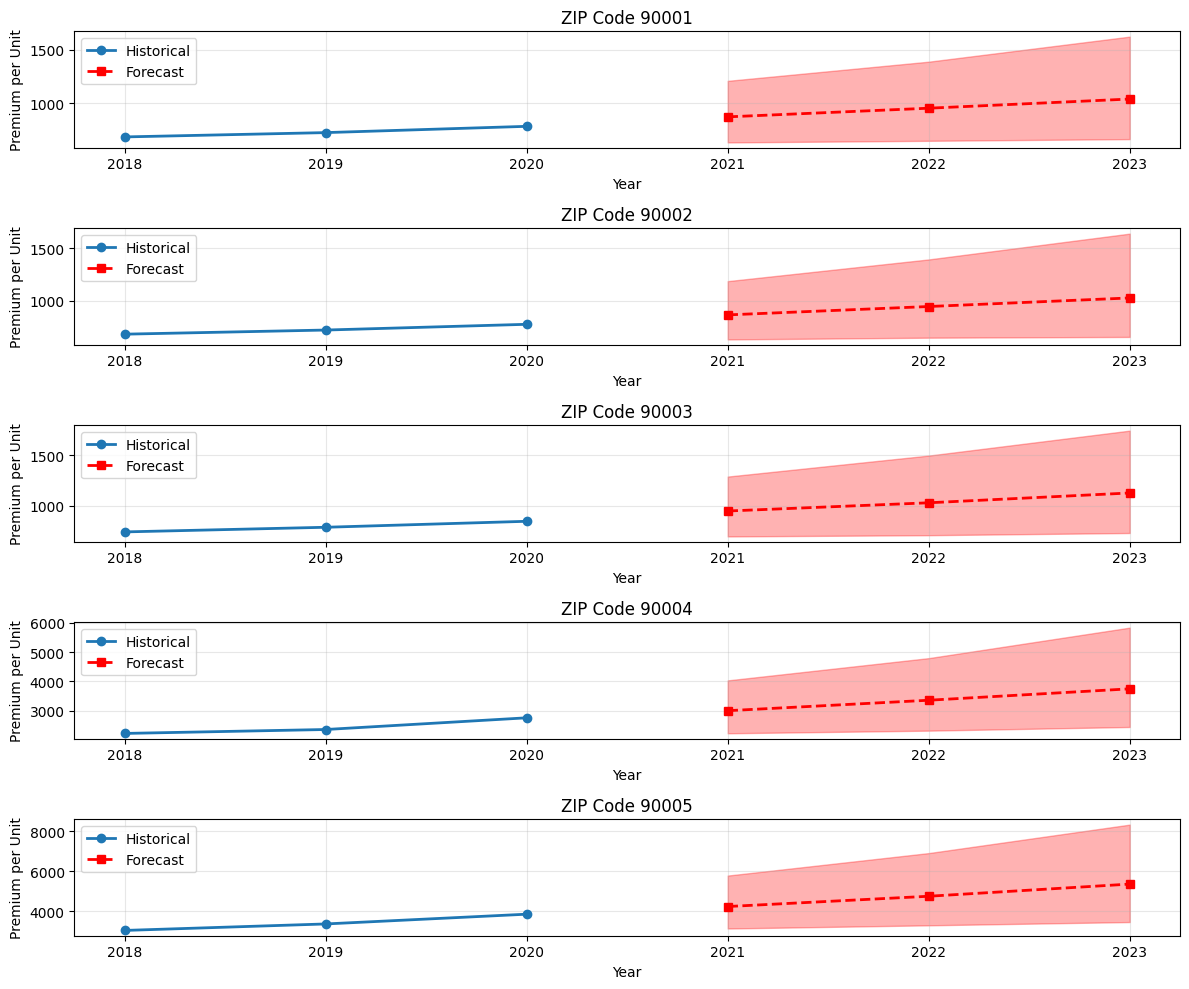

In [634]:
import matplotlib.pyplot as plt

# Visualize for some sample zipcodes
sample_zipcodes = final_df_bayes["zipcode"].unique()[:5]

fig, axes = plt.subplots(len(sample_zipcodes), 1, figsize=(12, 10))

for idx, zipcode in enumerate(sample_zipcodes):
    ax = axes[idx]
    
    hist = final_df_bayes[final_df_bayes["zipcode"] == zipcode]
    ax.plot(hist["yr"], np.exp(hist["log_prem_per_unit"]), 
            'o-', label="Historical", linewidth=2)
    
    forecast = final_forecasts[final_forecasts["zipcode"] == zipcode]
    ax.plot(forecast["year"], forecast["predicted_mean"], 
            's--', label="Forecast", linewidth=2, color='red')
    ax.fill_between(forecast["year"], 
                     forecast["predicted_lower"],
                     forecast["predicted_upper"],
                     alpha=0.3, color='red')
    
    ax.set_title(f"ZIP Code {zipcode}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Premium per Unit")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()